## Section 1: Initial Import from Github

In [114]:
import sys
import os
import pandas as pd
import geopandas as gpd
#Ensure Python can find the Code directory
sys.path.append(os.path.abspath(".."))

import utils

In [115]:
#Use functions and packages
df = utils.load_data()
df.head()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

## Section 2: Historical Background
- https://www.history.com/news/racially-restrictive-housing-covenants
- 

## Section 3: Data Bias Analysis

In [117]:
#Code Block 1
# Initial Exploration of Hennepin County Data
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.groupby('tract_minority_population_percent')['property_value'].describe()

,count,mean,std,min,25%,50%,75%,max
tract_minority_population_percent,,,,,,,,
0.00,574.0,2.328049e+05,2.718248e+05,5000.0,75000.0,160000.0,325000.0,4005000.0
2.03,24.0,2.970833e+05,1.214041e+05,125000.0,162500.0,315000.0,365000.0,545000.0
2.57,17.0,2.255882e+05,9.397277e+04,105000.0,155000.0,215000.0,265000.0,435000.0
2.60,31.0,4.359677e+05,2.166311e+05,155000.0,275000.0,335000.0,605000.0,895000.0
2.66,34.0,5.020588e+05,2.566277e+05,85000.0,277500.0,510000.0,722500.0,945000.0
2.67,17.0,3.508824e+05,1.814545e+05,145000.0,215000.0,335000.0,415000.0,755000.0
2.92,13.0,4.442308e+05,2.949142e+05,135000.0,205000.0,345000.0,585000.0,1145000.0
3.16,26.0,4.407692e+05,2.178288e+05,35000.0,297500.0,420000.0,610000.0,795000.0
3.39,11.0,1.831818e+05,1.183062e+05,55000.0,75000.0,185000.0,270000.0,385000.0


In [118]:
# Code Block 2
# View Value Counts of Minority Population Percentages
# This will help us understand the distribution of minority population percentages across the tracts
df['tract_minority_population_percent'].value_counts()

tract_minority_population_percent
0.00     1016
20.69     649
27.78     580
10.98     573
14.61     441
9.08      432
9.90      425
19.51     420
9.20      416
13.89     384
13.70     368
25.47     367
10.67     358
16.77     315
29.71     312
28.48     302
39.67     301
19.52     301
22.37     296
29.78     292
13.25     277
23.34     277
44.30     269
22.94     262
10.15     261
6.98      261
7.47      257
13.27     256
19.75     254
25.01     250
14.63     244
9.68      238
7.60      236
12.22     235
16.54     231
27.05     229
21.98     227
26.42     226
11.49     221
33.03     218
9.97      215
24.05     214
18.30     212
20.63     211
20.55     211
18.44     207
9.74      206
12.45     204
11.26     203
10.14     202
27.42     200
6.63      199
78.20     199
9.16      198
5.94      197
23.61     197
35.37     197
6.22      196
14.17     196
19.23     196
18.80     195
11.00     193
8.78      191
18.12     191
15.93     190
19.17     189
9.83      188
10.00     188
21.85     187


In [119]:
# Code Block 3
# Created by ChatGPT 40o to assist with grouping 'tract_minority_population_percent' into bins 

# Define the bins and labels
bins = [0, 25, 50, 75, 100]
labels = ['0-25%', '26-50%', '51-75%', '76-100%']

# Create a new column for the binned data
df['minority_population_group'] = pd.cut(df['tract_minority_population_percent'], bins=bins, labels=labels, right=False)

# Group by the new column and describe the property_value
grouped = df.groupby('minority_population_group')['property_value'].describe()

#Create a new dataframe from the grouped data for readability
df_grouped=grouped.reset_index()

df_grouped

C:\Users\autum\AppData\Local\Temp\ipykernel_3264\2860928199.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('minority_population_group')['property_value'].describe()


,minority_population_group,count,mean,std,min,25%,50%,75%,max
0,0-25%,54964.0,411135.470490,8.997391e+05,5000.0,235000.0,345000.0,475000.0,81605000.0
1,26-50%,22082.0,399984.149986,1.805664e+06,15000.0,245000.0,315000.0,405000.0,111325000.0
2,51-75%,4438.0,302338.891393,8.135939e+05,5000.0,225000.0,275000.0,325000.0,47405000.0
3,76-100%,2007.0,260112.107623,2.572401e+05,55000.0,195000.0,235000.0,285000.0,8555000.0


In [120]:
# Code Block 4
# View updated dataframe with binned data
df.head()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density,minority_population_group
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN,26-50%
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN,0-25%
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN,0-25%
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN,0-25%
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN,0-25%


### Differences in 0-25% minority_population_tract_percent and 76-100% minority_population_tract_percent

- For the 0-25% minority_population_group
    - property stats
        - count: 54,964
        - average(value): $411,135
        - median: $345,000
        - max: $81,605,000
- VS. 

- For the 76-100% minority_population_group
    - property stats
        - count: 2,007
        - average(value): $260,112
        - median: $235,000
        - max: $8,555,000

In [121]:
# Code Block 5
# Importing additional libraries for visulaization

import matplotlib.pyplot as plt
import seaborn as sns

<Axes: title={'center': 'Mean Property Value by Minority Population Percentage'}, xlabel='Minority Population Group', ylabel='Mean Property Value ($)'>

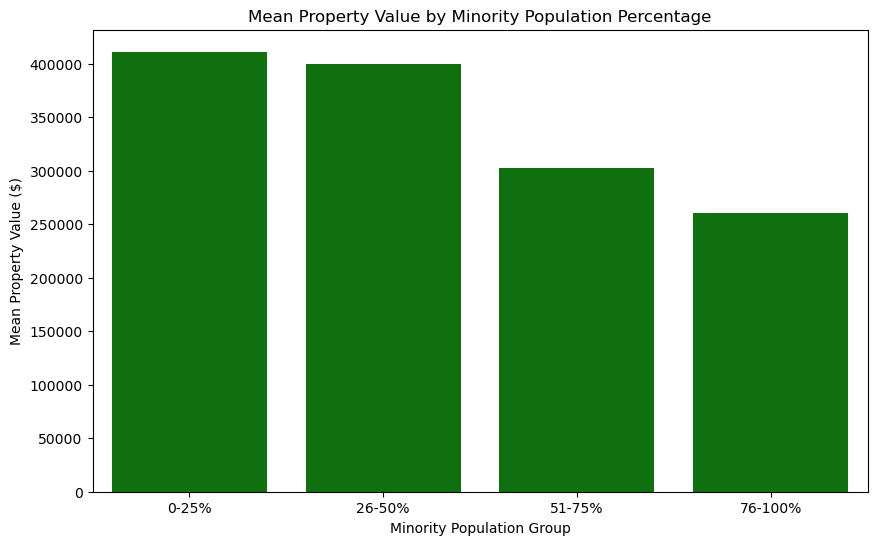

In [122]:
#Code Block 6
#Create a bar chart for average property value by minority population percentage group


plt.figure(figsize=(10, 6))
plt.xlabel("Minority Population Group")
plt.ylabel("Mean Property Value ($)")
plt.title("Mean Property Value by Minority Population Percentage")

sns.barplot(x= 'minority_population_group', y= 'property_value', data=df, errorbar= None, color="green")

<Axes: title={'center': 'Median Property Value by Minority Population Percentage'}, xlabel='Minority Population Group', ylabel='Median Property Value ($)'>

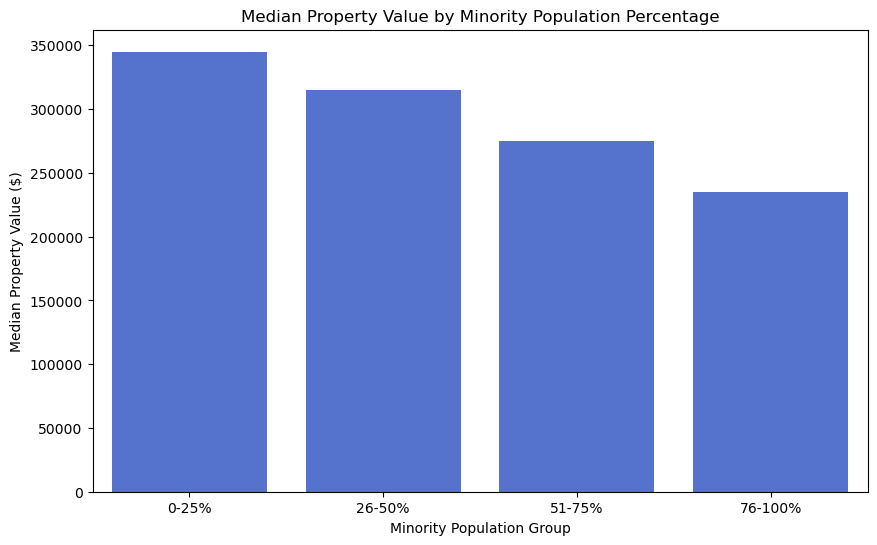

In [123]:
# Code Block 7
# Create a bar plot for median property values by minority population percentage 

#Grouped with use of Chat GPT40o

data = {
    'minority_population_group': ['0-25%', '26-50%', '51-75%', '76-100%'],
    'mean': [411135, 399944, 302338, 266110],
    'median': [345000, 315000, 275000, 235000],
    'min': [5000, 15000, 5000, 55000],
    'max': [8165000, 11132500, 4745000, 8555000]
}

# Create a DataFrame
df_viz = pd.DataFrame(data)

# Set the figure size
plt.figure(figsize=(10, 6))


plt.xlabel("Minority Population Group")
plt.ylabel("Median Property Value ($)")
plt.title("Median Property Value by Minority Population Percentage")

sns.barplot(x='minority_population_group', y='median', data = df_viz, errorbar=None, color="royalblue")




In [124]:
# Code Block 8
#  View value counts for covenant_count
df['covenant_count'].value_counts()

covenant_count
0.0      89762
1.0        684
3.0        532
2.0        488
212.0      294
9.0        293
4.0        281
7.0        241
13.0       216
10.0       191
188.0      189
60.0       188
22.0       178
213.0      167
68.0       159
12.0       157
110.0      155
205.0      154
88.0       134
63.0       132
965.0      126
76.0       125
132.0      125
70.0       119
539.0      113
28.0       112
653.0      107
317.0      106
482.0      105
130.0      103
71.0       100
292.0      100
93.0        99
82.0        98
32.0        98
38.0        97
39.0        97
64.0        97
410.0       96
8.0         92
128.0       92
925.0       92
196.0       90
19.0        89
351.0       89
403.0       88
100.0       85
173.0       84
48.0        83
327.0       82
875.0       81
143.0       79
349.0       78
69.0        77
332.0       76
315.0       75
87.0        71
195.0       71
362.0       71
359.0       70
168.0       69
145.0       69
232.0       69
461.0       68
150.0       67
259.0     

In [125]:
# Code Block 9
# View summary statistics for covenant_count
df['covenant_count'].describe()

count    100931.000000
mean         17.408101
std          84.973673
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         965.000000
Name: covenant_count, dtype: float64

In [126]:
#Code Block 10
# Group by minority population group and view summary statistics for covenant_count

df.groupby('minority_population_group')['covenant_count'].describe()

C:\Users\autum\AppData\Local\Temp\ipykernel_3264\1973316941.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('minority_population_group')['covenant_count'].describe()


,count,mean,std,min,25%,50%,75%,max
minority_population_group,,,,,,,,
0-25%,66877.0,18.089448,92.237341,0.0,0.0,0.0,0.0,965.0
26-50%,26333.0,17.377549,73.567155,0.0,0.0,0.0,0.0,561.0
51-75%,5244.0,16.863463,56.179480,0.0,0.0,0.0,1.0,359.0
76-100%,2477.0,0.490109,1.194530,0.0,0.0,0.0,0.0,4.0


In [127]:
#Code Block 11
#View stats for was approved by minority population group
df.groupby('minority_population_group')['was_approved'].describe()

C:\Users\autum\AppData\Local\Temp\ipykernel_3264\2280584053.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('minority_population_group')['was_approved'].describe()


,count,unique,top,freq
minority_population_group,,,,
0-25%,66877,2,True,45151
26-50%,26333,2,True,17195
51-75%,5244,2,True,3286
76-100%,2477,2,True,1453


C:\Users\autum\AppData\Local\Temp\ipykernel_3264\3619631258.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot (x= 'minority_population_group' , y= 'was_approved', data=df, errorbar=None, palette ="colorblind")


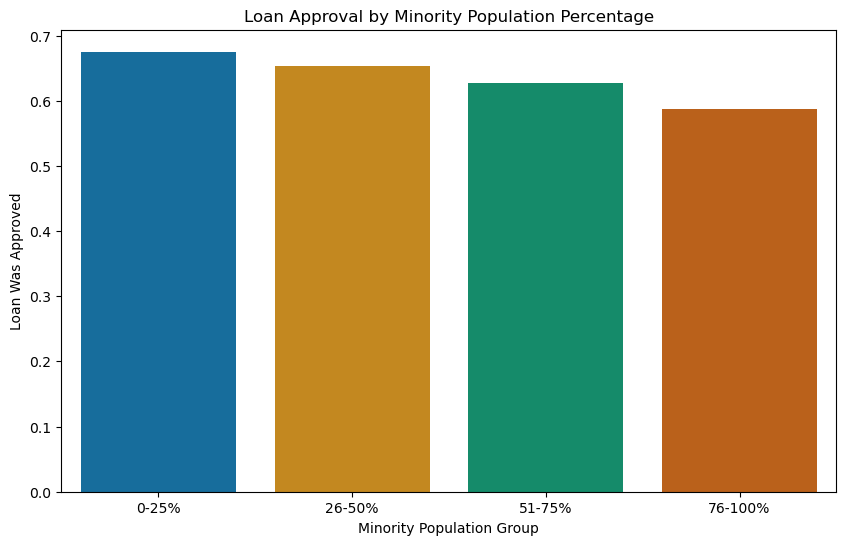

In [128]:
#Code Block 12
# Create a bar plot for loan approvals  by minority population percentage

plt.figure(figsize=(10, 6))
plt.xlabel("Minority Population Group")
plt.ylabel("Loan Was Approved")
plt.title("Loan Approval by Minority Population Percentage")   
sns.barplot (x= 'minority_population_group' , y= 'was_approved', data=df, errorbar=None, palette ="colorblind")
plt.show()


In [ ]:
#Code Block 13
# Viewing values for approval by race
df.groupby('derived_race')['was_approved'].describe().sort_values(by='freq', ascending=False)
 

,count,unique,top,freq
derived_race,,,,
White,63627,2,True,48106
Race Not Available,22811,2,False,13556
Asian,5905,2,True,4179
Black or African American,5199,2,True,3141
Joint,2427,2,True,1806
American Indian or Alaska Native,709,2,True,441
2 or more minority races,135,2,True,89
Native Hawaiian or Other Pacific Islander,113,2,True,64
Free Form Text Only,5,2,True,4


In [ ]:
#Code Block 14
#Rename "Free Form Text Only" and "Joint" based on information from HMDA Derived Fields Categorization Wiki

df['derived_race'] = df['derived_race'].replace({'Free Form Text Only': 'Race Not Available', 'Joint': 'White Multi Racial'})
df.groupby('derived_race')['was_approved'].describe().sort_values(by='freq', ascending=False)

,count,unique,top,freq
derived_race,,,,
White,63627,2,True,48106
Race Not Available,22816,2,False,13557
Asian,5905,2,True,4179
Black or African American,5199,2,True,3141
White Multi Racial,2427,2,True,1806
American Indian or Alaska Native,709,2,True,441
2 or more minority races,135,2,True,89
Native Hawaiian or Other Pacific Islander,113,2,True,64


C:\Users\autum\AppData\Local\Temp\ipykernel_3264\1236174830.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot (x= 'derived_race' , y= 'was_approved', data=df, errorbar=None, palette ="colorblind")


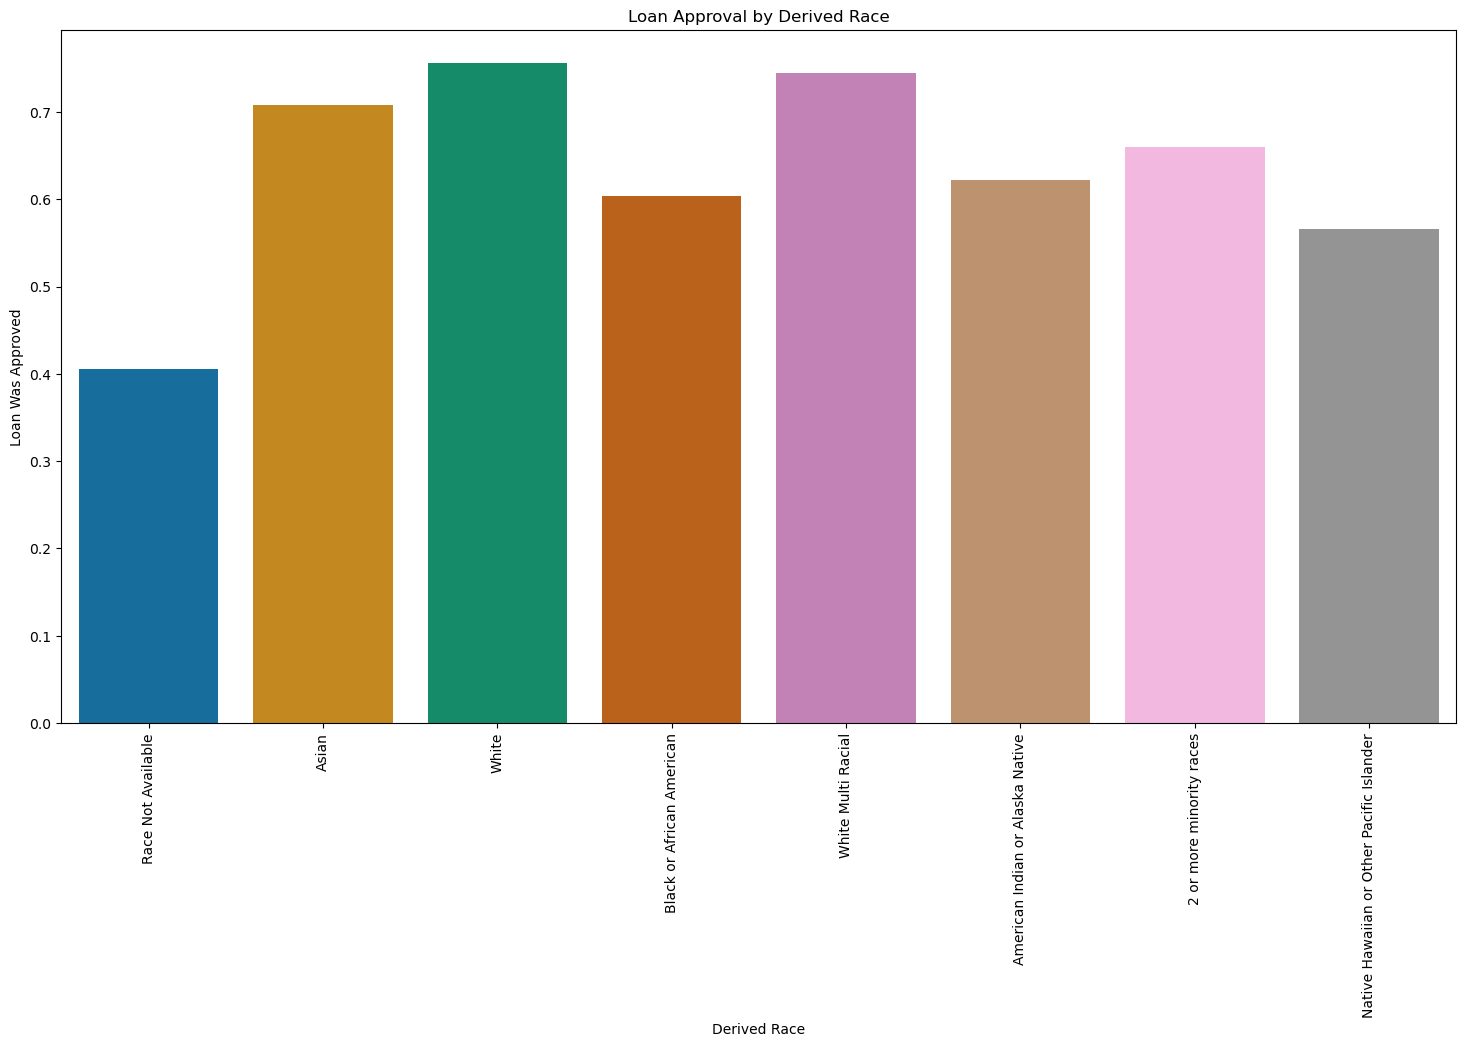

In [ ]:
#Code Block 15
#Plot Loan Approval Rates by Derived Race

plt.figure(figsize=(18, 9))
plt.xlabel("Derived Race")
plt.ylabel("Loan Was Approved")
plt.title("Loan Approval by Derived Race")   
sns.barplot (x= 'derived_race' , y= 'was_approved', data=df, errorbar=None, palette ="colorblind")
plt.xticks(rotation=90)
plt.show()


In [ ]:
#Code Block 16
#Creating a grouped data for minority population and derived race to view approval rates on multiple levels
#Used ChatGPT4o for assistance with grouping

approval_rate_by_group_and_race = df.groupby(['minority_population_group', 'derived_race'])['was_approved'].mean()
print(approval_rate_by_group_and_race)


C:\Users\autum\AppData\Local\Temp\ipykernel_3264\3840678571.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_rate_by_group_and_race = df.groupby(['minority_population_group', 'derived_race'])['was_approved'].mean()


minority_population_group  derived_race                             
0-25%                      2 or more minority races                     0.673913
                           American Indian or Alaska Native             0.622426
                           Asian                                        0.710792
                           Black or African American                    0.623911
                           Native Hawaiian or Other Pacific Islander    0.547945
                           Race Not Available                           0.389511
                           White                                        0.764694
                           White Multi Racial                           0.756410
26-50%                     2 or more minority races                     0.672414
                           American Indian or Alaska Native             0.611111
                           Asian                                        0.718608
                           Black or Afri

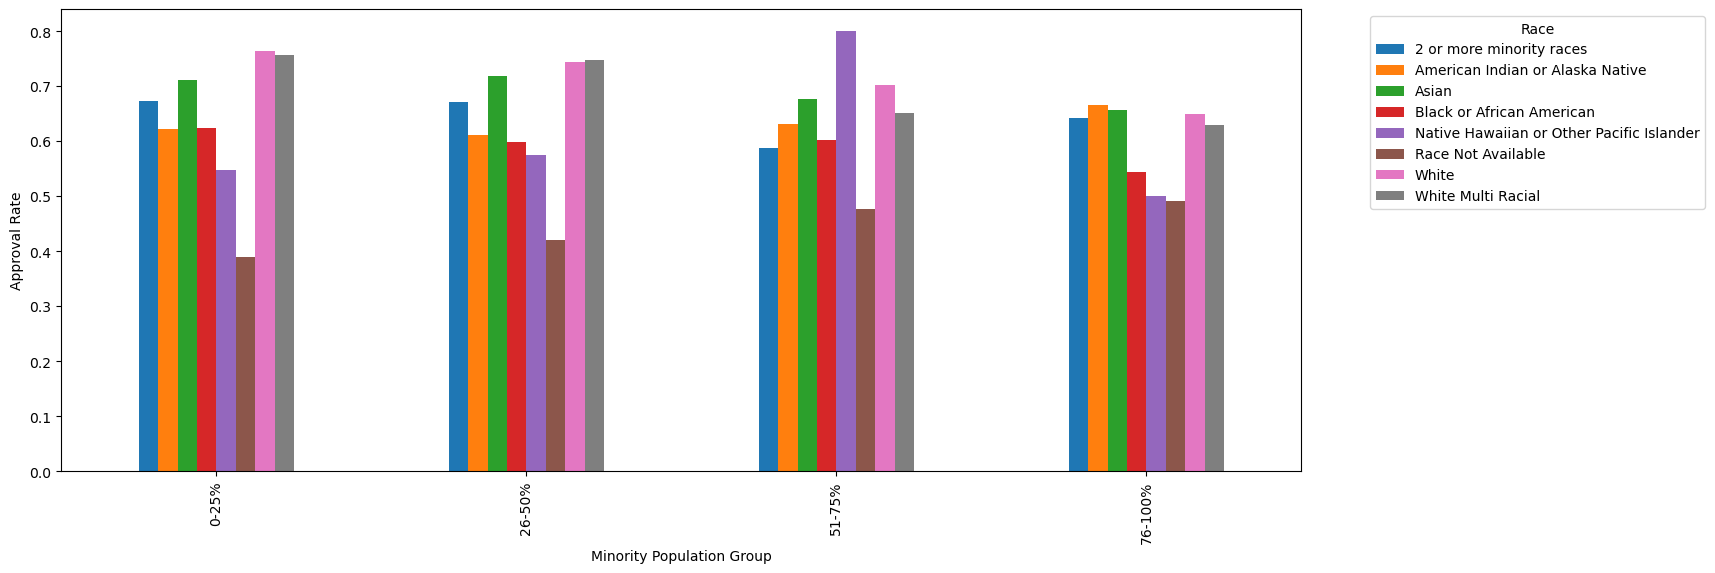

In [ ]:
#Code Block 17

# Plot the grouped bar chart
approval_rate_by_group_and_race.unstack().plot(kind='bar', figsize=(16,6))

plt.ylabel("Approval Rate")
plt.xlabel("Minority Population Group")
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc='upper left') # Move the legend outside the plot
plt.show()



In [ ]:
#Code Block 18 
#View tract to msa income percentage by minority population group
## Description from ffiec.cfpb.gov: Percentage of tract median family income compared to MSA/MD median family income
### An MSA/MD is an area that has at least one urbanized area of 50,000 or more population

df.groupby('minority_population_group')['tract_to_msa_income_percentage'].describe()

C:\Users\autum\AppData\Local\Temp\ipykernel_3264\2458561272.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('minority_population_group')['tract_to_msa_income_percentage'].describe()


,count,mean,std,min,25%,50%,75%,max
minority_population_group,,,,,,,,
0-25%,66877.0,109.268446,30.516020,0.00,91.57,106.18,123.98,240.43
26-50%,26333.0,94.881380,29.830190,0.00,75.48,90.00,105.83,236.76
51-75%,5244.0,66.680932,16.195774,29.57,54.81,68.08,73.59,165.22
76-100%,2477.0,48.613117,10.628443,28.55,41.59,49.19,53.45,89.68


- tract_to_msa_income_percentage definition from: https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields#tract_to_msa_income_percentage
    - Description: Percentage of tract median family income compared to MSA/MD median family income
- derived_msa-md
    - Description: The 5 digit derived MSA (metropolitan statistical area) or MD (metropolitan division) code. An MSA/MD is an area that has at least one urbanized area of 50,000 or more population
- What does this mean: 
    - If an average tract_to_msa_income_percentage is above 100% then the mean income for those on this tract is above the MSA average in general
    - If an average tract_to_msa_income_percentage is below 100% then the mean income for those on this tract is below the MSA average in general


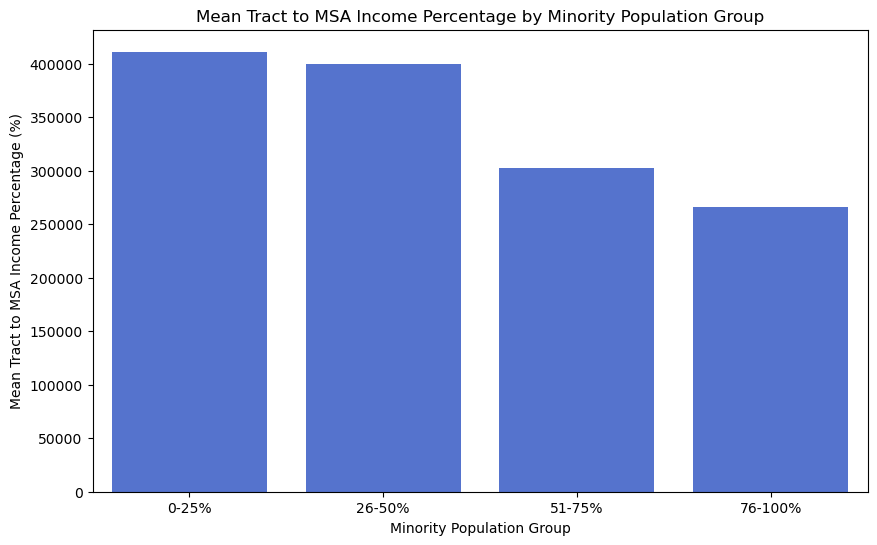

In [ ]:
#Code Block 19
#Create a Visualization for Mean Tract MSA Income Percentage by Minority Population Group 

# Sample data based on your provided summary statistics CHAT GPT40o assisted with grouping for the visualization
data = {
    'minority_population_group': ['0-25%', '26-50%', '51-75%', '76-100%'],
    'mean': [109.27, 94.88, 66.68, 48.61],  # Mean tract-to-MSA income percentage
    'median': [106.18, 90.00, 68.08, 49.19],  # Median tract-to-MSA income percentage
    'min': [0.00, 0.00, 29.57, 28.55],  # Minimum values
    'max': [240.43, 236.76, 165.22, 89.68]  # Maximum values
}

# Create a DataFrame
df_tract_income_perct = pd.DataFrame(data)

# Create the bar plot
plt.figure(figsize=(10, 6))

sns.barplot(x=df_viz["minority_population_group"], y=df_viz["mean"], color="royalblue")
plt.xlabel("Minority Population Group")
plt.ylabel("Mean Tract to MSA Income Percentage (%)")
plt.title("Mean Tract to MSA Income Percentage by Minority Population Group")

plt.show()


In [ ]:
#Code Block 20
#Import Ramsey County Data

df_ramsey_cov=pd.read_csv('Data/Ramsey_County_Racial_Covenants_Table.csv', index_col=None, header=0)
df_MN = pd.read_csv('Data/state_MN.csv',index_col=None, header=0, low_memory=False)


In [ ]:
# Code Block 21
# View Ramsey County Info
df_ramsey_cov.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5457 entries, 0 to 5456
Data columns (total 36 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   db_id       5457 non-null   int64  
 1   workflow    5457 non-null   int64  
 2   cnty_name   5457 non-null   object 
 3   cnty_fips   5457 non-null   int64  
 4   doc_num     5349 non-null   object 
 5   deed_year   5457 non-null   int64  
 6   deed_date   5457 non-null   object 
 7   exec_date   0 non-null      float64
 8   cov_text    5457 non-null   object 
 9   seller      2915 non-null   object 
 10  buyer       119 non-null    object 
 11  street_add  5457 non-null   object 
 12  city        5457 non-null   object 
 13  state       5457 non-null   object 
 14  zip_code    5457 non-null   int64  
 15  add_cov     5457 non-null   object 
 16  block_cov   5446 non-null   object 
 17  lot_cov     5457 non-null   object 
 18  cnty_pin    5457 non-null   int64  
 19  add_mod     5457 non-null  

In [ ]:
# Code Block 22
# View header for Ramsey County
df_ramsey_cov.head()

,db_id,workflow,cnty_name,cnty_fips,doc_num,deed_year,deed_date,exec_date,cov_text,seller,buyer,street_add,city,state,zip_code,add_cov,block_cov,lot_cov,cnty_pin,add_mod,block_mod,lot_mod,ph_dsc_mod,join_strgs,geocd_addr,geocd_dist,cov_type,match_type,manual_cx,dt_updated,zn_subj_id,zn_dt_ret,image_ids,med_score,plat_dbid,subd_dbid
0,121778,1,Ramsey,27123,62278,1923,1923-07-30,NaN,The party of the second part hereby agrees tha...,Oric O. & Louise F. Whited,NaN,1641 JUNO AVE,ST PAUL,MN,55116,benedictine plat 1,NONE,23,92823410117,BENEDICTINE PLAT 1,NaN,23,LOT 23,benedictine plat 1 block none lot 23,NaN,NaN,manual,Public submission (single property),True,2024-02-13 20:16:09.492556+00:00,NaN,NaN,",,",NaN,1635.0,NaN
1,10042,1,Ramsey,27123,238504,1946,1946-12-06,NaN,"No lot or parcel shall ever be sold, conveyed,...","Siems Bros, Inc.",NaN,3500 GLENARDEN RD,ARDEN HILLS,MN,55112,arden hills no. 2,4,"3,4,5,6,7,8,9,10,11,12,13,14,15",343023210062,ARDEN HILLS NO. 2,4,13,N 1/2 OF LOT 14 AND ALL OF LOT 13 BLK 4,arden hills 2 block 4 lot 10;arden hills 2 blo...,NaN,NaN,manual,Something else,True,2024-02-13 20:07:42.878392+00:00,NaN,NaN,",,",NaN,2211.0,NaN
2,129679,1,Ramsey,27123,191287,1941,1941-03-31,NaN,no person or persons other than of the Caucasi...,"Louise F. Dye, widow",NaN,7350 SILVER LAKE RD,MOUNDS VIEW,MN,55112,spring lake park knolls,NONE,115,73023240042,"SPRING LAKE PARK KNOLLS,,RAMSE",NaN,115,EX N 50 FT LOT 116 AND EX S 28 FT LOT 115,spring lake park knolls block none lot 115,NaN,NaN,manual,Public submission (single property),True,2024-02-13 20:49:10.892857+00:00,NaN,NaN,",,",NaN,2104.0,NaN
3,129717,1,Ramsey,27123,183271,1940,1940-03-14,NaN,no person or persons other than of the Caucasi...,"Louise F. Dye, widow",NaN,7405 SPRING LAKE RD,MOUNDS VIEW,MN,55112,spring lake park knolls,NONE,87,73023230032,"SPRING LAKE PARK KNOLLS,,RAMSE",NaN,87,LOT 87,spring lake park knolls block none lot 87,NaN,NaN,manual,Public submission (single property),True,2024-02-13 20:52:51.012077+00:00,NaN,NaN,",,",NaN,2104.0,NaN
4,129748,1,Ramsey,27123,90965,1942,1942-01-17,NaN,no person or persons other than of the Caucasi...,"Bronson-Erickson, Inc.",NaN,3032 BRONSON DR,MOUNDS VIEW,MN,55112,spring lake park knolls,NONE,63,73023230001,"SPRING LAKE PARK KNOLLS,,RAMSE",NaN,63,E 9O FT OF LOTS 63 AND LOT 64,spring lake park knolls block none lot 63,NaN,NaN,manual,Public submission (single property),True,2024-02-13 20:53:03.816099+00:00,NaN,NaN,",,",NaN,2104.0,NaN
